In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv('application_metadata (2).csv')

In [3]:
data.head()

,customer_ref,application_id,application_hour,application_day_of_week,account_open_year,preferred_contact,referral_code,account_status_code,random_noise_1,num_login_sessions,num_customer_service_calls,has_mobile_app,paperless_billing,default
0,10000,620515,5,6,2013,Mail,REF0000,ACT-2,1.137099,13,2,1,1,0
1,10001,624978,4,2,2015,Phone,REF0000,ACT-3,-0.164932,6,1,1,1,1
2,10002,564658,10,3,2020,Phone,REF0000,ACT-3,0.526700,1,2,1,0,0
3,10003,621493,7,5,2010,Email,REF0000,A01,-0.709779,4,1,1,1,0
4,10004,637785,1,2,2020,Mail,REF0000,ACT-3,-0.603132,6,2,1,0,0


In [7]:
matricx = data.corr(numeric_only=True)

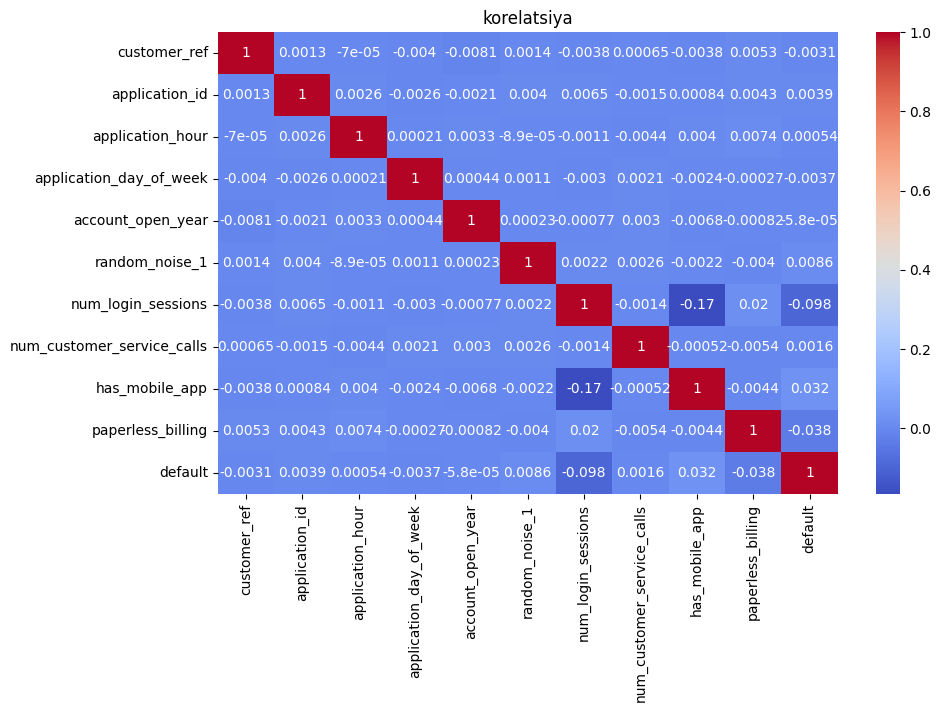

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(matricx,annot=True,cmap="coolwarm")
plt.title("korelatsiya")
plt.show()

In [9]:
feature_colums = [
    "application_hour","application_day_of_week","account_open_year","preferred_contact",
    "referral_code","account_status_code","random_noise_1","num_login_sessions","num_customer_service_calls",
    "has_mobile_app","paperless_billing"
]

In [10]:
X = data[feature_colums]
Y = data["default"]

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [12]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

In [15]:
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(x_train,y_train)
lgb_pred = lgb_model.predict_proba(x_test)[:,-1]
lgb_aus = roc_auc_score(y_test,lgb_pred)
print("LightGBM  AUC: ", lgb_aus)

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: preferred_contact: object, referral_code: object, account_status_code: object

In [21]:
data.shape

(89999, 14)

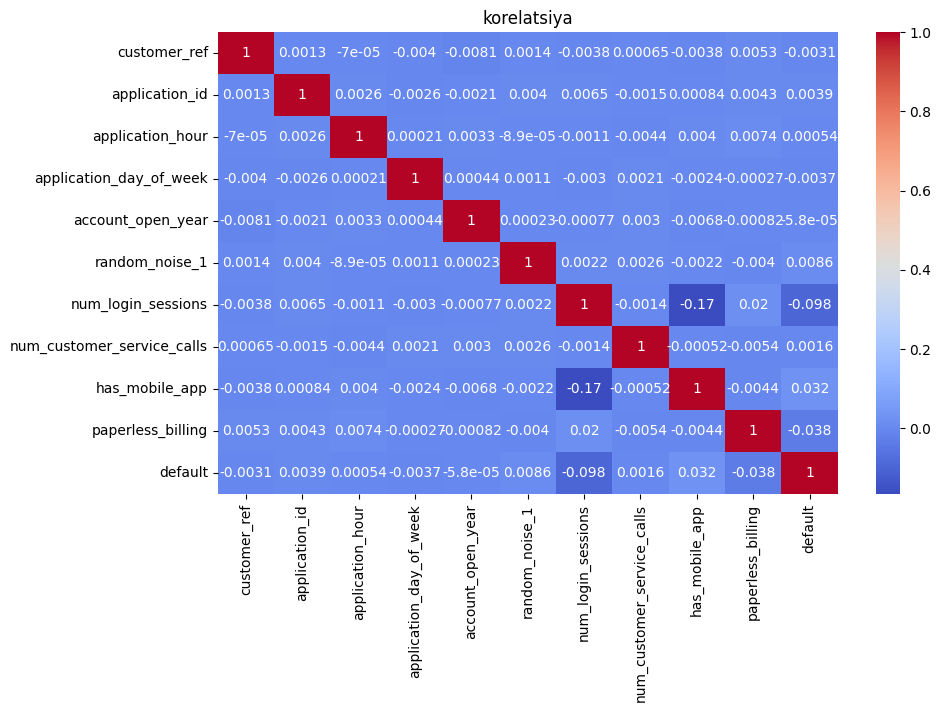

[LightGBM] [Info] Number of positive: 3656, number of negative: 68343
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 357
[LightGBM] [Info] Number of data points in the train set: 71999, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050778 -> initscore=-2.928169
[LightGBM] [Info] Start training from score -2.928169
LightGBM AUC: 0.6272702228096252


In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

# Load data
data = pd.read_csv('application_metadata (2).csv')

# Correlation
matricx = data.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(matricx, annot=True, cmap="coolwarm")
plt.title("korelatsiya")
plt.show()

# Features
feature_colums = [
    "application_hour","application_day_of_week","account_open_year","preferred_contact",
    "account_status_code","random_noise_1","num_login_sessions",
    "num_customer_service_calls","has_mobile_app","paperless_billing"
]

X = data[feature_colums].copy()
Y = data["default"]

# ---- FIX: convert object columns to category ----
cat_cols = ["preferred_contact", "account_status_code"]
for col in cat_cols:
    X[col] = X[col].astype("category")

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# LightGBM
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(x_train, y_train)

# Predict
lgb_pred = lgb_model.predict_proba(x_test)[:,-1]
lgb_auc = roc_auc_score(y_test, lgb_pred)

print("LightGBM AUC:", lgb_auc)


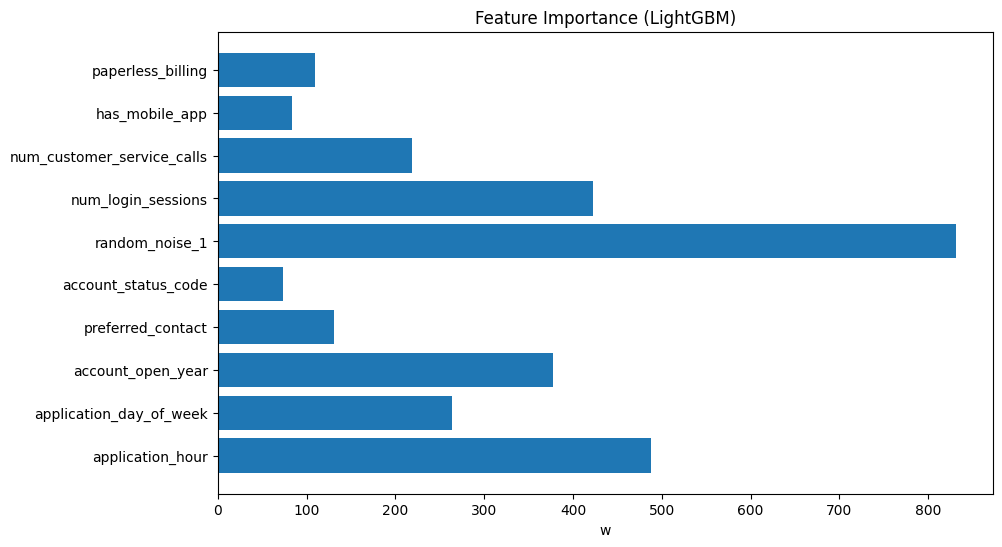

In [20]:
w = lgb_model.feature_importances_
s = x_train.columns


plt.figure(figsize=(10,6))
plt.barh(s,w)
plt.xlabel("w")
plt.title("Feature Importance (LightGBM)")
plt.show()

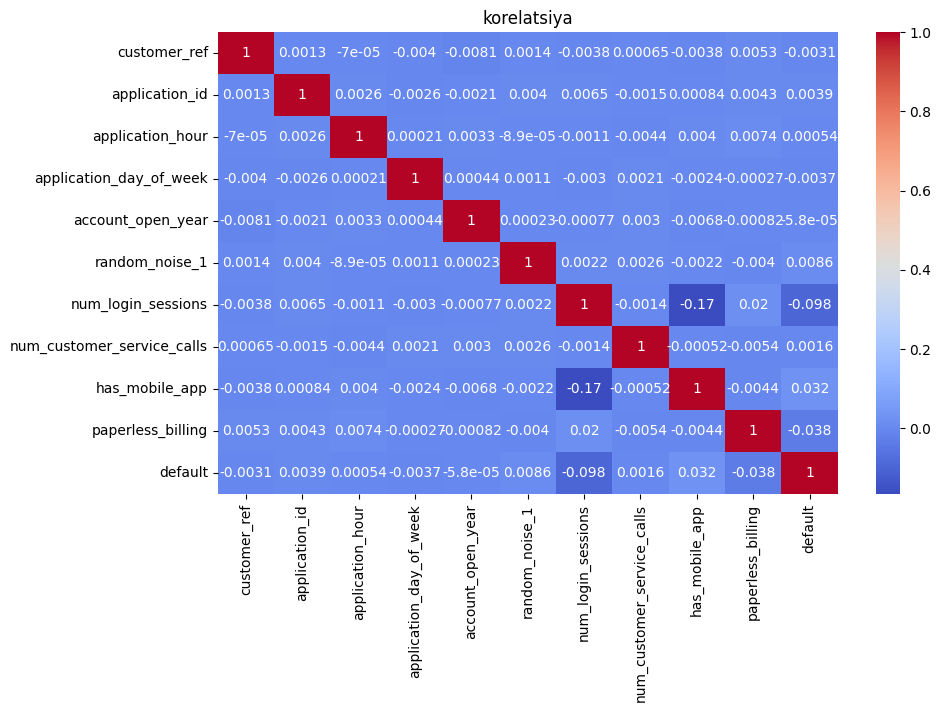

[LightGBM] [Info] Number of positive: 3656, number of negative: 68343
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004266 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 357
[LightGBM] [Info] Number of data points in the train set: 71999, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050778 -> initscore=-2.928169
[LightGBM] [Info] Start training from score -2.928169
LightGBM AUC: 0.6272702228096252


In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

# ======================================================
# 1) Load data
# ======================================================
data = pd.read_csv('application_metadata (2).csv')

# ======================================================
# 2) Remove duplicates
# ======================================================
data.drop_duplicates(inplace=True)

# ======================================================
# 3) Remove columns with only one unique value
# ======================================================
for col in data.columns:
    if data[col].nunique() == 1:
        data.drop(col, axis=1, inplace=True)

# ======================================================
# 4) Fill missing values
# ======================================================

# Numeric columns → median
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# Object/category columns → most frequent value
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# ======================================================
# 5) Convert object columns to category (LightGBM best practice)
# ======================================================
for col in cat_cols:
    data[col] = data[col].astype("category")

# ======================================================
# 6) Correlation
# ======================================================
matricx = data.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(matricx, annot=True, cmap="coolwarm")
plt.title("korelatsiya")
plt.show()

# ======================================================
# 7) Select features
# ======================================================
feature_colums = [
    "application_hour","application_day_of_week","account_open_year","preferred_contact",
    "account_status_code","random_noise_1","num_login_sessions",
    "num_customer_service_calls","has_mobile_app","paperless_billing"
]

X = data[feature_colums].copy()
Y = data["default"]

# ======================================================
# 8) Train-test split
# ======================================================
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# ======================================================
# 9) LightGBM Model
# ======================================================
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(x_train, y_train)

# ======================================================
# 10) Prediction & AUC
# ======================================================
lgb_pred = lgb_model.predict_proba(x_test)[:, -1]
lgb_auc = roc_auc_score(y_test, lgb_pred)

print("LightGBM AUC:", lgb_auc)


In [ ]:
data1 = pd.read_json('financial_ratios.jsonl', lines=True)

In [26]:
data1.shape

(89999, 16)

In [27]:
data1.head()

,cust_num,monthly_income,existing_monthly_debt,monthly_payment,debt_to_income_ratio,debt_service_ratio,payment_to_income_ratio,credit_utilization,revolving_balance,credit_usage_amount,available_credit,total_monthly_debt_payment,annual_debt_payment,loan_to_annual_income,total_debt_amount,monthly_free_cash_flow
0,10000,"5,150.00",738.64,$592.13,0.258,0.258402,0.115,0.841,"$142,213.10","$142,213.10","$26,886.90",1330.77,15969.24,0.286408,"159,913.10","3,819.23"
1,10001,"2,383.33",392.21,"1,013.86",0.590,0.589959,0.425,0.971,"$75,932.20","75,932.20","$2,267.80",1406.07,16872.84,3.986014,"189,932.20",$977.26
2,10002,"1,725.00",204.07,$317.81,0.303,0.302539,0.184,0.539,22314.6,"22,314.60","$19,085.40",521.88,6262.56,0.449275,31614.6,1203.12
3,10003,"2,616.67",$288.71,234.52,0.200,0.199961,0.090,0.147,"8,820.00",8820.0,"51,180.00",523.23,6278.76,0.277070,"$17,520.00",2093.4366666666665
4,10004,"2,050.00",$248.77,334.81,0.285,0.284673,0.163,0.488,24253.6,24253.6,"25,446.40",583.58,7002.96,0.292683,"$31,453.60",1466.42


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

# ====================================================
# 1) Faylni o‘qish (JSONL yoki CSV)
# ====================================================
file_path = 'financial_ratios.jsonl'  # sizning fayl nomingiz
data = pd.read_json(file_path, lines=True)

# ====================================================
# 2) Pul ustunlarini float ga aylantirish
# ====================================================
money_cols = [
    'monthly_income','existing_monthly_debt','monthly_payment',
    'revolving_balance','credit_usage_amount','available_credit',
    'total_debt_amount'
]

for col in money_cols:
    if col in data.columns:
        data[col] = data[col].astype(str)\
                             .str.replace('$','',regex=False)\
                             .str.replace(',','',regex=False)
        data[col] = pd.to_numeric(data[col], errors='coerce')

# ====================================================
# 3) Qolgan raqam ustunlarini float ga aylantirish
# ====================================================
numeric_cols = [
    'debt_to_income_ratio','debt_service_ratio','payment_to_income_ratio',
    'credit_utilization','total_monthly_debt_payment','annual_debt_payment',
    'loan_to_annual_income'
]

for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# ====================================================
# 4) NaN qiymatlarni median bilan to‘ldirish
# ====================================================
data = data.fillna(data.median(numeric_only=True))

# ====================================================
# 5) Object ustunlarini categorical ga aylantirish
# ====================================================
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    data[col] = data[col].astype('category')

# ====================================================
# 6) Features va target
# ====================================================
# Target ustunini aniqlang, masalan "default"
target_col = 'monthly_free_cash_flow'  # agar sizning target boshqacha bo‘lsa o‘zgartiring
feature_cols = [c for c in data.columns if c != target_col]

X = data[feature_cols]
Y = data[target_col]

# ====================================================
# 7) Train-test split
# ====================================================
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# ====================================================
# 8) LightGBM modelini o‘qitish
# ====================================================
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(x_train, y_train)

# ====================================================
# 9) Predict va AUC hisoblash
# ====================================================
lgb_pred = lgb_model.predict_proba(x_test)[:,-1]
lgb_auc = roc_auc_score(y_test, lgb_pred)

print("LightGBM AUC:", lgb_auc)

# ====================================================
# 10) Dataset preview
# ====================================================
print(data.head())


c:\Users\behru\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
